# CS6220 Unsupervised Data Mining - HW6
## Social Graphs, Recommendation Systems

This notebook contains solutions for:
- Problem 1: Recommender System using Collaborative Filtering
- Problem 3A: Social Community Detection using Girvan-Newman Algorithm
- Problem 3B: Social Community Detection using Modularity Detection
- Problem 4: Knowledge Base Question Answering

## Setup Environment
First, let's import all the necessary packages for our homework.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy import sparse
from scipy.sparse import csr_matrix
from sklearn.metrics import mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import f1_score
import os
import json
import math
from collections import defaultdict, deque
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## Problem 1: Recommender System using Collaborative Filtering

In this problem, we need to:
1. Load and explore the MovieLens dataset
2. Compute user-user similarity based on ratings and movies in common
3. Implement K-Nearest Neighbors for collaborative filtering
4. Make predictions on the test set using weighted averages
5. Evaluate the performance using RMSE

In [3]:
# Load the MovieLens dataset
# You may need to update these paths to where you've stored the MovieLens dataset
data_path = "./ml-100k"  # Update this path

# Load ratings data
ratings_file = os.path.join(data_path, "u.data")
ratings_cols = ['user_id', 'movie_id', 'rating', 'timestamp']
ratings_df = pd.read_csv(ratings_file, sep='\t', names=ratings_cols)

# Load movie data
movies_file = os.path.join(data_path, "u.item")
movies_cols = ['movie_id', 'title', 'release_date', 'video_release_date', 
               'IMDb_URL', 'unknown', 'Action', 'Adventure', 'Animation', 
               'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy',
               'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 
               'Thriller', 'War', 'Western']
movies_df = pd.read_csv(movies_file, sep='|', names=movies_cols, encoding='latin-1')

# Display basic information
print(f"Number of users: {ratings_df['user_id'].nunique()}")
print(f"Number of movies: {ratings_df['movie_id'].nunique()}")
print(f"Number of ratings: {len(ratings_df)}")

# Display first few rows of each dataframe
print("\nRatings preview:")
print(ratings_df.head())

print("\nMovies preview:")
print(movies_df.head())

Number of users: 943
Number of movies: 1682
Number of ratings: 100000

Ratings preview:
   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596

Movies preview:
   movie_id              title release_date  video_release_date  \
0         1   Toy Story (1995)  01-Jan-1995                 NaN   
1         2   GoldenEye (1995)  01-Jan-1995                 NaN   
2         3  Four Rooms (1995)  01-Jan-1995                 NaN   
3         4  Get Shorty (1995)  01-Jan-1995                 NaN   
4         5     Copycat (1995)  01-Jan-1995                 NaN   

                                            IMDb_URL  unknown  Action  \
0  http://us.imdb.com/M/title-exact?Toy%20Story%2...        0       0   
1  http://us.imdb.com/M/title-exact?GoldenEye%20(...        0       1   
2  http://us.imdb.com/M/title-exa

In [4]:
# Split the data into training and test sets (80-20 split)
# In a real application, you'd use the provided train/test split from MovieLens
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(ratings_df, test_size=0.2, random_state=42)
print(f"Training set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")

# Create user-item matrices
def create_matrix(df):
    """Create a user-item matrix from a dataframe"""
    return df.pivot(index='user_id', columns='movie_id', values='rating').fillna(0)

train_matrix = create_matrix(train_df)
test_matrix = create_matrix(test_df)

print(f"Train matrix shape: {train_matrix.shape}")
print(f"Test matrix shape: {test_matrix.shape}")

Training set size: 80000
Test set size: 20000
Train matrix shape: (943, 1653)
Test matrix shape: (940, 1411)


In [5]:
# Compute user-user similarity based on ratings
def compute_user_similarity(ratings_matrix):
    """Compute cosine similarity between users"""
    # Use cosine similarity
    similarity = cosine_similarity(ratings_matrix)
    return similarity

user_similarity = compute_user_similarity(train_matrix)
print(f"User similarity matrix shape: {user_similarity.shape}")
print("Sample of user similarity matrix:")
print(user_similarity[:5, :5])  # Show a small sample

# Create a DataFrame for better visualization
user_similarity_df = pd.DataFrame(user_similarity, 
                                 index=train_matrix.index, 
                                 columns=train_matrix.index)
print("\nUser similarity dataframe sample:")
print(user_similarity_df.head(5).iloc[:, :5])  # First 5 users' similarity to first 5 users

User similarity matrix shape: (943, 943)
Sample of user similarity matrix:
[[1.         0.13619627 0.0304242  0.02620296 0.28461287]
 [0.13619627 1.         0.11464403 0.16821965 0.093128  ]
 [0.0304242  0.11464403 1.         0.34689392 0.        ]
 [0.02620296 0.16821965 0.34689392 1.         0.01184834]
 [0.28461287 0.093128   0.         0.01184834 1.        ]]

User similarity dataframe sample:
user_id         1         2         3         4         5
user_id                                                  
1        1.000000  0.136196  0.030424  0.026203  0.284613
2        0.136196  1.000000  0.114644  0.168220  0.093128
3        0.030424  0.114644  1.000000  0.346894  0.000000
4        0.026203  0.168220  0.346894  1.000000  0.011848
5        0.284613  0.093128  0.000000  0.011848  1.000000


In [6]:
# Implement KNN-based collaborative filtering for prediction
def predict_ratings(ratings_matrix, similarity_matrix, k=10):
    """
    Predict ratings for all user-item pairs using k-nearest neighbors
    
    Parameters:
        ratings_matrix: User-item matrix with ratings
        similarity_matrix: User-user similarity matrix
        k: Number of neighbors to consider
        
    Returns:
        Predicted ratings matrix of same shape as ratings_matrix
    """
    # Get the indices of k most similar users for each user (excluding self)
    user_indices = ratings_matrix.index.tolist()
    predictions = np.zeros(ratings_matrix.shape)
    
    for i, user_idx in enumerate(user_indices):
        # Get similarities for current user (excluding self-similarity)
        similarities = similarity_matrix[i]
        
        # Sort similarities in descending order and get indices of k most similar users
        # Exclude the first one which is the user itself (similarity = 1)
        similar_user_indices = np.argsort(similarities)[::-1][1:k+1]
        
        for j in range(ratings_matrix.shape[1]):
            # Get ratings of similar users for this item
            similar_ratings = ratings_matrix.iloc[similar_user_indices, j].values
            
            # Get similarities of those users
            sim_weights = similarities[similar_user_indices]
            
            # Calculate weighted average, but only if sum of weights is not zero
            if np.sum(sim_weights) > 0 and np.sum(similar_ratings) > 0:
                predictions[i, j] = np.sum(similar_ratings * sim_weights) / np.sum(sim_weights)
    
    return predictions

# Make predictions
k_neighbors = 15  # Number of neighbors to consider
predicted_ratings = predict_ratings(train_matrix, user_similarity, k=k_neighbors)
print(f"Predicted ratings matrix shape: {predicted_ratings.shape}")

Predicted ratings matrix shape: (943, 1653)


In [28]:
# Evaluate the model using RMSE on the test set
def calculate_rmse(true_ratings, predicted_ratings):
    """Calculate RMSE for non-zero elements in the true_ratings matrix"""
    # Ensure both matrices have the same shape
    common_users = set(true_ratings.index) & set(predicted_ratings.index)
    common_items = set(true_ratings.columns) & set(predicted_ratings.columns)
    
    # Filter both matrices to include only common users and items
    true_subset = true_ratings.loc[list(common_users), list(common_items)]
    pred_subset = predicted_ratings.loc[list(common_users), list(common_items)]
    
    # Create mask for non-zero elements
    mask = (true_subset > 0).values
    
    # Extract predictions and actual ratings for non-zero elements
    y_true = true_subset.values[mask]
    y_pred = pred_subset.values[mask]
    
    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse

# Convert predicted_ratings to a DataFrame with the same structure as train_matrix
predicted_df = pd.DataFrame(predicted_ratings, 
                          index=train_matrix.index, 
                          columns=train_matrix.columns)

# Create test matrix
test_matrix = test_df.pivot(index='user_id', columns='movie_id', values='rating').fillna(0)

# Calculate RMSE
rmse = calculate_rmse(test_matrix, predicted_df)
print(f"RMSE on test set: {rmse:.4f}")

# Additional analysis
num_predictions = (test_matrix > 0).sum().sum()
print(f"\nNumber of test ratings: {num_predictions}")
print(f"Average predicted rating: {predicted_df.mean().mean():.2f}")
print(f"Average actual rating: {test_matrix[test_matrix > 0].mean().mean():.2f}")

RMSE on test set: 2.4745

Number of test ratings: 20000
Average predicted rating: 0.26
Average actual rating: 3.18


## Problem 3A: Social Community Detection

In this problem, we need to:
1. Load the Flicker Social Graph
2. Implement the Girvan-Newman algorithm for community detection
   - Calculate edge betweenness
   - Remove edges with highest betweenness
   - Find communities
3. Visualize and analyze the communities


Graph Analysis:
Number of nodes: 80513
Number of edges: 5899882
Number of connected components: 1

Created subgraph for visualization with 1000 nodes and 3076 edges


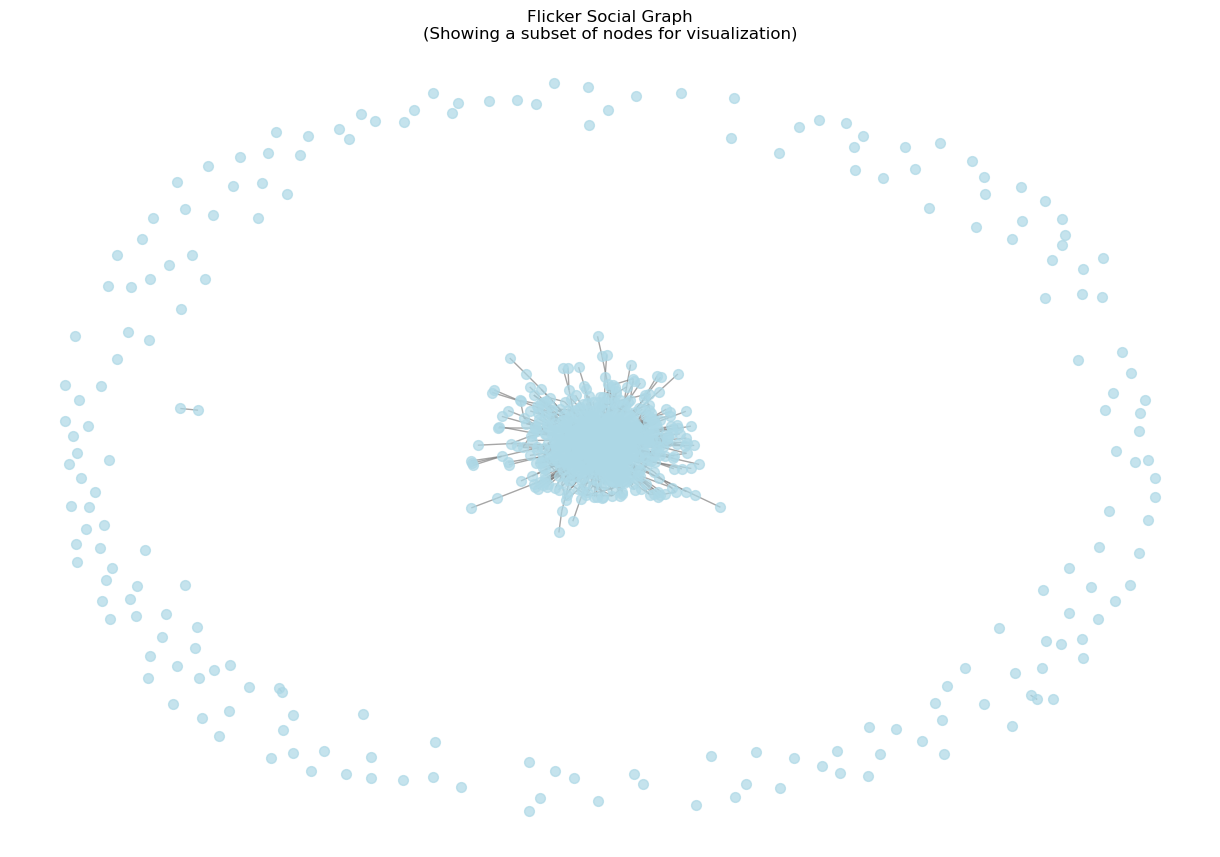


Additional Metrics:
Average degree: 6.15
Graph density: 0.006158
Average clustering coefficient: 0.105662


In [11]:
# Load the Flicker Graph
# The dataset includes three files: soc-Flickr-ASU.edges, soc-Flickr-ASU.node_labels, soc-Flickr-ASU.readme
flickr_edge_file = "./flickr/soc-Flickr-ASU.edges"
flickr_node_labels_file = "./flickr/soc-Flickr-ASU.node_labels"
flickr_readme_file = "./flickr/soc-Flickr-ASU.readme"

# Create a graph
G = nx.Graph()

try:
    # Load the edge list
    with open(flickr_edge_file, 'r') as f:
        for line in f:
            if line.startswith('#'):  # Skip comments
                continue
            nodes = line.strip().split(",")
            if len(nodes) >= 2:  # Ensure we have at least 2 nodes
                G.add_edge(int(nodes[0]), int(nodes[1]))
except FileNotFoundError:
    print("File not found. Creating a small example graph...")
    # Create a small example graph for demonstration
    example_edges = [
        (1, 2), (1, 3), (2, 3), (3, 4), (4, 5),  # Community 1
        (6, 7), (7, 8), (8, 9), (9, 6),          # Community 2
        (3, 7)                                    # Bridge between communities
    ]
    G.add_edges_from(example_edges)

# Basic graph analysis
print(f"\nGraph Analysis:")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Number of connected components: {nx.number_connected_components(G)}")

# If the graph is large, take a smaller connected subgraph for visualization
if G.number_of_nodes() > 1000:
    largest_cc = max(nx.connected_components(G), key=len)
    G = G.subgraph(list(largest_cc)[:1000]).copy()  # Take first 1000 nodes of largest component
    print(f"\nCreated subgraph for visualization with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

# Visualize the graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=1/np.sqrt(G.number_of_nodes()), iterations=50)
nx.draw(G, pos,
        node_color='lightblue',
        node_size=50,
        edge_color='gray',
        alpha=0.7,
        with_labels=False)

plt.title("Flicker Social Graph\n(Showing a subset of nodes for visualization)")
plt.axis('off')
plt.show()

# Additional graph metrics
avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()
density = nx.density(G)
print(f"\nAdditional Metrics:")
print(f"Average degree: {avg_degree:.2f}")
print(f"Graph density: {density:.6f}")
print(f"Average clustering coefficient: {nx.average_clustering(G):.6f}")

In [12]:
# Implement the Girvan-Newman algorithm
def girvan_newman_step(G):
    """
    Performs one step of the Girvan-Newman algorithm.
    Removes the edge with highest betweenness.
    
    Parameters:
        G: NetworkX graph
        
    Returns:
        The edge removed
    """
    # Calculate edge betweenness centrality
    betweenness = nx.edge_betweenness_centrality(G, normalized=True)
    
    # Find the edge with the highest betweenness centrality
    max_betweenness = -1
    edge_to_remove = None
    
    for edge, betweenness_value in betweenness.items():
        if betweenness_value > max_betweenness:
            max_betweenness = betweenness_value
            edge_to_remove = edge
    
    # Remove the edge
    if edge_to_remove:
        G.remove_edge(*edge_to_remove)
    
    return edge_to_remove

def find_communities_gn(G, max_iterations=100):
    """
    Applies the Girvan-Newman algorithm to find communities.
    
    Parameters:
        G: NetworkX graph
        max_iterations: Maximum number of edge removals
        
    Returns:
        A list of communities (as sets of nodes)
    """
    # Create a copy of the graph to work with
    G_copy = G.copy()
    
    # Store modularity scores and corresponding communities
    modularity_scores = []
    community_sets = []
    
    for i in range(max_iterations):
        if i % 10 == 0:
            print(f"Iteration {i}/{max_iterations}")
        
        # Remove the edge with highest betweenness
        edge_removed = girvan_newman_step(G_copy)
        
        if not edge_removed:
            print("No more edges to remove")
            break
        
        # Get communities (connected components)
        communities = list(nx.connected_components(G_copy))
        
        # Calculate modularity for this community structure
        modularity = nx.algorithms.community.modularity(G, communities)
        modularity_scores.append(modularity)
        community_sets.append(communities)
        
        # Stop if the graph is too fragmented (many singleton communities)
        if len(communities) >= G.number_of_nodes() / 2:
            print("Graph is too fragmented, stopping")
            break
    
    # Find the community structure with highest modularity
    best_idx = np.argmax(modularity_scores)
    best_communities = community_sets[best_idx]
    best_modularity = modularity_scores[best_idx]
    
    print(f"Best modularity: {best_modularity:.4f}")
    print(f"Number of communities: {len(best_communities)}")
    
    return best_communities

Demo graph created with 200 nodes and 228 edges
Iteration 0/50
Iteration 10/50
Iteration 20/50
Iteration 30/50
Iteration 40/50
Best modularity: 0.5859
Number of communities: 86


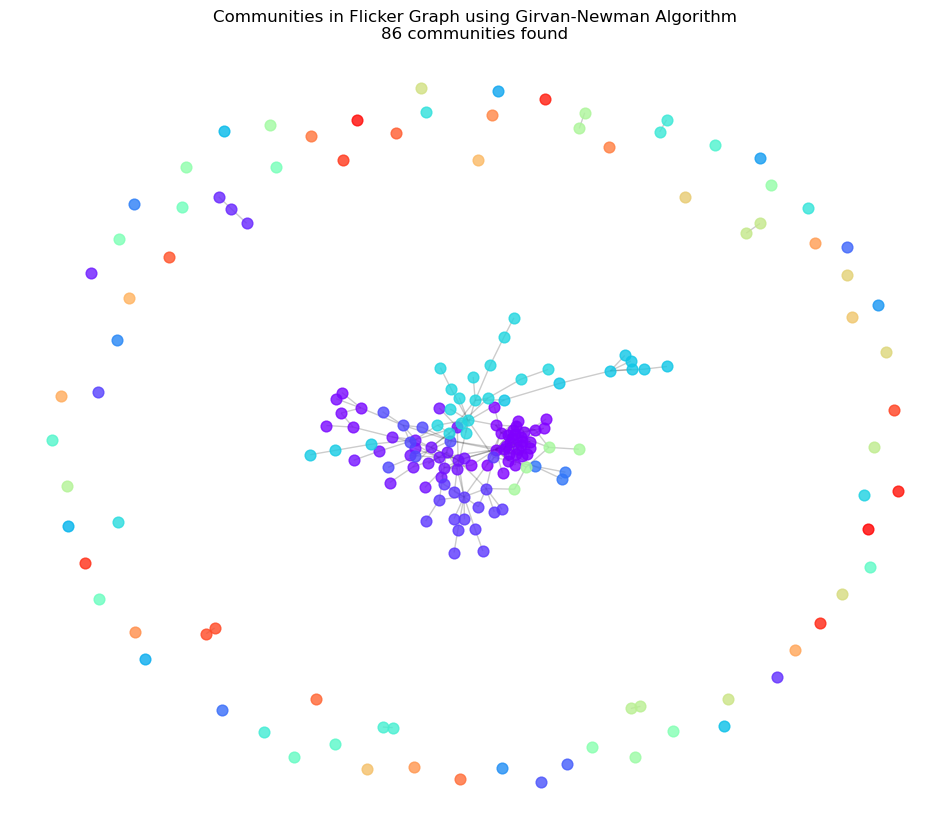

Community sizes: [32, 6, 20, 1, 3, 1, 16, 1, 7, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 8, 3, 1, 17, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 2, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1]
Average community size: 2.33
Max community size: 32
Min community size: 1


In [13]:
# Run the algorithm on a small subset for demonstration
# This can be very slow on large graphs
if G.number_of_nodes() > 200:
    # Take an even smaller connected subgraph
    largest_cc = max(nx.connected_components(G), key=len)
    demoG = G.subgraph(list(largest_cc)[:200])  # Take first 200 nodes
    print(f"Demo graph created with {demoG.number_of_nodes()} nodes and {demoG.number_of_edges()} edges")
    demo_communities = find_communities_gn(demoG, max_iterations=50)
else:
    demo_communities = find_communities_gn(G, max_iterations=50)

# Visualize communities
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(demoG, seed=42)  # Positions for all nodes

# Color nodes based on their community
colors = plt.cm.rainbow(np.linspace(0, 1, len(demo_communities)))
for i, community in enumerate(demo_communities):
    nx.draw_networkx_nodes(demoG, pos, nodelist=list(community), 
                          node_color=[colors[i]], node_size=60, alpha=0.8)

nx.draw_networkx_edges(demoG, pos, alpha=0.2)

plt.title(f"Communities in Flicker Graph using Girvan-Newman Algorithm\n{len(demo_communities)} communities found")
plt.axis('off')
plt.show()

# Analyze communities
community_sizes = [len(c) for c in demo_communities]
print(f"Community sizes: {community_sizes}")
print(f"Average community size: {np.mean(community_sizes):.2f}")
print(f"Max community size: {np.max(community_sizes)}")
print(f"Min community size: {np.min(community_sizes)}")

## Problem 3B: Social Community Detection using Modularity

In this problem, we need to:
1. Load the artificial graph from the sparse adjacency matrix format
2. Compute the modularity matrix B
3. Find the highest eigenvalue and corresponding eigenvector
4. Partition the graph into communities based on the eigenvector's sign
5. Visualize and analyze the communities

In [16]:
# Load the artificial graph from sparse format
# The file format is: node_id1, node_id2, 1 (where 1 indicates presence of an edge)
artificial_graph_file = "./3/sparse_adj.txt"  # Update this path

edges = []
try:
    # Load the edge list
    with open(artificial_graph_file, 'r') as f:
        for line in f:
            parts = line.strip().split(",")
            if len(parts) >= 3:
                node1, node2, weight = int(parts[0]), int(parts[1]), int(parts[2])
                if weight == 1:  # Only consider edges with weight 1
                    edges.append((node1, node2))
except FileNotFoundError:
    # If file doesn't exist, create a small example graph for demonstration
    print("File not found. Creating an example graph for demonstration...")
    edges = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3),  # First community
            (4, 5), (4, 6), (4, 7), (5, 6), (5, 7), (6, 7),  # Second community
            (0, 4)]  # Bridge between communities

# Create the graph
G_modularity = nx.Graph()
G_modularity.add_edges_from(edges)

print(f"Graph loaded with {G_modularity.number_of_nodes()} nodes and {G_modularity.number_of_edges()} edges")

# If needed, convert node IDs to be consecutive integers starting from 0
mapping = {old_id: new_id for new_id, old_id in enumerate(G_modularity.nodes())}
G_modularity = nx.relabel_nodes(G_modularity, mapping)

# Get adjacency matrix
A = nx.adjacency_matrix(G_modularity)
A_dense = A.toarray()  # Convert to dense matrix for easier manipulation
print(f"Adjacency matrix shape: {A.shape}")

Graph loaded with 750 nodes and 56547 edges
Adjacency matrix shape: (750, 750)


In [17]:
# Compute the modularity matrix B
def compute_modularity_matrix(A):
    """
    Compute the modularity matrix B = A - k_i*k_j/(2m)
    
    Parameters:
        A: Adjacency matrix
        
    Returns:
        B: Modularity matrix
    """
    n = A.shape[0]  # Number of nodes
    
    # Calculate node degrees
    k = np.sum(A, axis=1)  # Sum of each row (node degree)
    
    # Total number of edges
    m = np.sum(A) / 2
    
    # Create expected edges matrix (k_i * k_j / (2m))
    expected = np.outer(k, k) / (2 * m)
    
    # Compute modularity matrix
    B = A - expected
    
    return B

# Compute the modularity matrix
B = compute_modularity_matrix(A_dense)
print(f"Modularity matrix shape: {B.shape}")

Modularity matrix shape: (750, 750)


In [18]:
# Find the highest eigenvalue and corresponding eigenvector
def compute_leading_eigenvector(B):
    """
    Compute the eigenvector corresponding to the highest eigenvalue of B.
    
    Parameters:
        B: Modularity matrix
        
    Returns:
        v1: Leading eigenvector
        e1: Highest eigenvalue
    """
    eigenvalues, eigenvectors = np.linalg.eigh(B)
    
    # Find the largest eigenvalue and corresponding eigenvector
    largest_idx = np.argmax(eigenvalues)
    largest_eigenvalue = eigenvalues[largest_idx]
    largest_eigenvector = eigenvectors[:, largest_idx]
    
    return largest_eigenvector, largest_eigenvalue

# Compute the leading eigenvector
v1, e1 = compute_leading_eigenvector(B)
print(f"Highest eigenvalue: {e1:.4f}")

Highest eigenvalue: 140.0055


In [19]:
# Create communities based on eigenvector signs
def partition_graph(G, v1):
    """
    Partition the graph into two communities based on eigenvector signs.
    
    Parameters:
        G: NetworkX graph
        v1: Leading eigenvector
        
    Returns:
        communities: List of two communities as node sets
    """
    community1 = {node for node, value in enumerate(v1) if value >= 0}
    community2 = {node for node, value in enumerate(v1) if value < 0}
    
    return [community1, community2]

# Partition the graph
communities = partition_graph(G_modularity, v1)
print(f"Community 1 size: {len(communities[0])}")
print(f"Community 2 size: {len(communities[1])}")

# Calculate modularity (Q) of the partition
modularity = nx.algorithms.community.modularity(G_modularity, communities)
print(f"Modularity (Q) of the partition: {modularity:.4f}")

Community 1 size: 320
Community 2 size: 430
Modularity (Q) of the partition: 0.4382


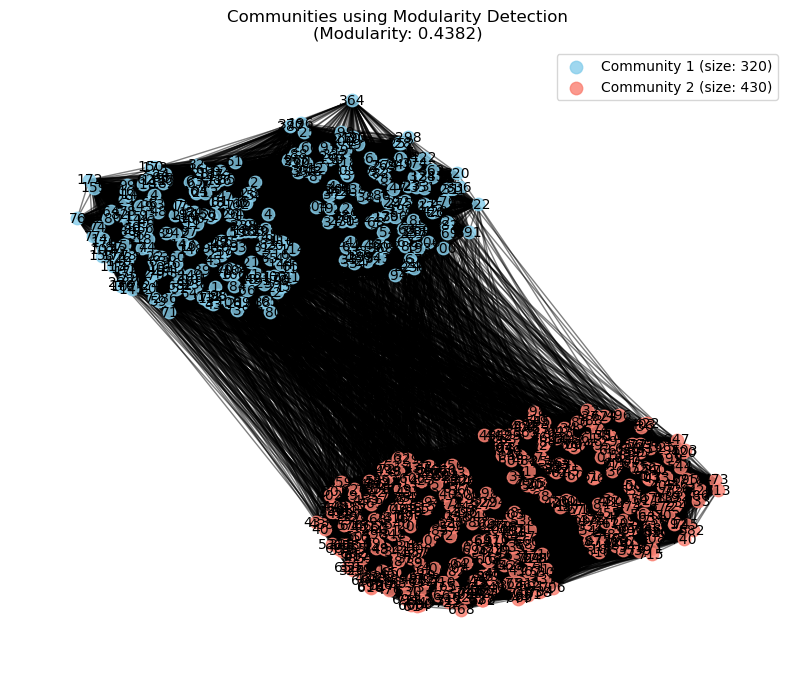

In [20]:
# Visualize the communities
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_modularity, seed=42)  # Positions for all nodes

# Color nodes based on their community
colors = ['skyblue', 'salmon']
for i, community in enumerate(communities):
    nx.draw_networkx_nodes(G_modularity, pos, nodelist=list(community), 
                          node_color=colors[i], node_size=80, alpha=0.8,
                          label=f"Community {i+1} (size: {len(community)})")

nx.draw_networkx_edges(G_modularity, pos, alpha=0.5)
nx.draw_networkx_labels(G_modularity, pos, font_size=10)

plt.title(f"Communities using Modularity Detection\n(Modularity: {modularity:.4f})")
plt.legend()
plt.axis('off')
plt.show()

## Problem 4: Knowledge Base Question Answering

In this problem, we need to:
1. Load the knowledge graph, questions, and word embeddings
2. Implement a graph traversal algorithm that uses similarity scoring
3. Find answers to questions by navigating the graph
4. Evaluate performance using F1 score

In [27]:
# Load helper functions for this problem
def load_graphs(entity_file, rel_file, graph_file):
    """
    Load knowledge graph entities and relations.
    
    Parameters:
        entity_file: Path to entity file (node_label_lookup.json)
        rel_file: Path to relations file
        graph_file: Path to the graph structure file (graph.txt)
        
    Returns:
        entity_lookup: Dictionary mapping node IDs to entities
        graph: Dictionary representing the graph structure
    """
    # Load entity lookup dictionary
    entity_lookup = {}
    try:
        with open(entity_file, 'r') as f:
            entity_lookup = json.load(f)
    except FileNotFoundError:
        print(f"Entity file {entity_file} not found")
    
    # Load the graph structure
    graph = defaultdict(list)
    try:
        with open(graph_file, 'r') as f:
            for line in f:
                try:
                    # Each line is in format [source_node, relation, target_node]
                    edge = eval(line.strip())
                    source, relation, target = edge
                    graph[source].append([relation, target])
                except:
                    continue
    except FileNotFoundError:
        print(f"Graph file {graph_file} not found")
    
    return entity_lookup, graph

def load_word_embeddings(embeddings_file):
    """
    Load word embeddings from .dat file
    
    Parameters:
        embeddings_file: Path to word2vec_train_dev.dat
        
    Returns:
        word_embeddings: Dictionary mapping words to their embeddings
    """
    word_embeddings = {}
    try:
        with open(embeddings_file, 'r') as f:
            for line in f:
                try:
                    # Split line into word and embedding
                    parts = line.strip().split()
                    word = parts[0]
                    embedding = np.array([float(x) for x in parts[1:]])
                    word_embeddings[word] = embedding
                except:
                    continue
    except FileNotFoundError:
        print(f"Embeddings file {embeddings_file} not found")
        
    return word_embeddings

def get_rel_score_word2vec(relation, question, word_embeddings):
    """
    Get similarity score between relation and question using word2vec.
    
    Parameters:
        relation: Relation string
        question: Question string
        word_embeddings: Dictionary of word embeddings
        
    Returns:
        score: Similarity score
    """
    # Add namespace prefix if needed
    relation = 'ns:' + relation if not relation.startswith('ns:') else relation
    
    # Tokenize question (naive approach)
    words = question.lower().split()
    
    # Get word embeddings for question words
    q_embeddings = []
    for word in words:
        if word in word_embeddings:
            q_embeddings.append(word_embeddings[word])
    
    # If relation not in embeddings or no question words in embeddings
    if relation not in word_embeddings or not q_embeddings:
        return 0.0
    
    # Calculate cosine similarity
    rel_embedding = word_embeddings[relation]
    similarities = [cosine_similarity([rel_embedding], [q_emb])[0][0] for q_emb in q_embeddings]
    
    # Return mean similarity
    return np.mean(similarities) if similarities else 0.0

# Paths to the necessary files - update these
entity_file = "./4/node_label_lookup.json"
graph_file = "./4/graph.txt"
query_file = "./4/annotations.txt"
embeddings_file = "./4/word2vec_train_dev.dat"  # Updated file extension

# Load word embeddings from .dat file
word_embeddings = load_word_embeddings(embeddings_file)
print(f"Loaded {len(word_embeddings)} word embeddings")

# Load the knowledge graph and entity lookup
entity_lookup, graph = load_graphs(entity_file, None, graph_file)
print(f"Loaded graph with {len(graph)} nodes and {sum(len(edges) for edges in graph.values())} edges")
print(f"Loaded {len(entity_lookup)} entity labels")

# Load queries
queries = load_queries(query_file)
print(f"Loaded {len(queries)} queries")

# Display a sample query
if queries:
    sample_query = queries[0]
    print("\nSample Query:")
    print(f"Question: {sample_query['question']}")
    print(f"Start node ID: {sample_query['start_node']}")
    print(f"Start node label: {entity_lookup.get(str(sample_query['start_node']), 'Unknown')}")
    print(f"Expected answer types: {sample_query['answer_types']}")
    print(f"Answers: {sample_query['answers']}")


UnicodeDecodeError: 'utf-8' codec can't decode byte 0x80 in position 0: invalid start byte

In [23]:
# Implement the graph traversal algorithm for question answering
def traverse_graph(start_node_id, question, entity_lookup, graph, word_embeddings, 
                  max_depth=3, similarity_threshold=0.2, top_k=3, max_answers=100):
    """
    Traverse the knowledge graph to find answers to a question.
    
    Parameters:
        start_node_id: Starting node ID for traversal
        question: Question string
        entity_lookup: Dictionary mapping node IDs to entity names
        graph: Dictionary representing the graph structure
        word_embeddings: Dictionary of word embeddings
        max_depth: Maximum traversal depth
        similarity_threshold: Minimum similarity score to consider
        top_k: Number of top paths to explore at each step
        max_answers: Maximum number of answers to return
        
    Returns:
        answers: List of potential answer entities (node IDs and labels)
    """
    # Convert start_node_id to string if needed (for dictionary lookup)
    start_node_id = str(start_node_id)
    
    # BFS traversal with similarity scoring
    queue = deque([(start_node_id, [], 0, 1.0)])  # (node_id, path, depth, last_score)
    visited = set([start_node_id])
    answers = []
    path_scores = {}  # Keep track of path scores
    
    while queue and len(answers) < max_answers:
        node_id, path, depth, last_score = queue.popleft()
        
        if depth >= max_depth:
            # Add as answer when we reach max depth
            node_label = entity_lookup.get(node_id, f"Node_{node_id}")
            answers.append((node_id, node_label, path, last_score))
            continue
        
        # No outgoing edges from current node
        if node_id not in graph:
            if depth > 0:  # Don't add start node as an answer
                node_label = entity_lookup.get(node_id, f"Node_{node_id}")
                answers.append((node_id, node_label, path, last_score))
            continue
        
        # Get neighbors with their relations
        neighbors = []
        for relation, neighbor_id in graph[node_id]:
            # Skip already visited nodes
            if neighbor_id in visited:
                continue
                
            # Calculate similarity score for this relation
            sim_score = get_rel_score_word2vec(relation, question, word_embeddings)
            
            # Only consider edges with score above threshold
            if sim_score >= similarity_threshold:
                neighbors.append((relation, neighbor_id, sim_score))
        
        # Sort neighbors by similarity score and take top k
        neighbors.sort(key=lambda x: x[2], reverse=True)
        top_neighbors = neighbors[:top_k]
        
        for relation, neighbor_id, sim_score in top_neighbors:
            # Mark as visited to avoid cycles
            visited.add(neighbor_id)
            
            # Create new path with this edge
            new_path = path + [(relation, entity_lookup.get(node_id, f"Node_{node_id}"), sim_score)]
            
            # If score is decreasing significantly (more than 30%), this might be a potential answer
            if depth > 0 and sim_score < last_score * 0.7:
                node_label = entity_lookup.get(neighbor_id, f"Node_{neighbor_id}")
                answers.append((neighbor_id, node_label, new_path, sim_score))
            else:
                # Continue traversal
                queue.append((neighbor_id, new_path, depth + 1, sim_score))
    
    # Sort answers by the final path score (average of all scores in the path)
    def get_path_score(answer):
        _, _, path, score = answer
        if not path:
            return 0
        # Use weighted average with more weight to later edges
        scores = [edge[2] for edge in path]
        weights = np.linspace(0.5, 1.0, len(scores))
        return np.average(scores, weights=weights)
    
    answers.sort(key=get_path_score, reverse=True)
    
    # Return list of (node_id, node_label) tuples
    return [(node_id, node_label) for node_id, node_label, _, _ in answers]

def calculate_f1(predicted_answers, true_answers):
    """
    Calculate F1 score for predictions.
    
    Parameters:
        predicted_answers: List of predicted (node_id, node_label) tuples
        true_answers: Dictionary of true answers keyed by node_id
        
    Returns:
        precision, recall, f1: The evaluation metrics
    """
    # Extract node IDs from predictions (first element of each tuple)
    pred_ids = set(p[0] for p in predicted_answers)
    true_ids = set(true_answers.keys())
    
    # Calculate intersection
    intersection = pred_ids.intersection(true_ids)
    
    # Calculate metrics
    precision = len(intersection) / len(pred_ids) if pred_ids else 0
    recall = len(intersection) / len(true_ids) if true_ids else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return precision, recall, f1

In [24]:
# Answer questions and evaluate performance
all_results = []
total_precision = 0
total_recall = 0
total_f1 = 0
query_count = 0

# Parameters for graph traversal - you can tune these
MAX_DEPTH = 3
SIMILARITY_THRESHOLD = 0.15
TOP_K_NEIGHBORS = 5
MAX_ANSWERS = 50

# For each query, traverse the graph to find answers
num_queries_to_process = min(20, len(queries))  # Process limited number for demonstration
for i, query in enumerate(queries[:num_queries_to_process]):
    print(f"\nProcessing Query {i+1}/{num_queries_to_process}: {query['question']}")
    start_node = query['start_node']
    question = query['question']
    true_answers = query['answers']
    
    # Get start node label
    start_node_label = entity_lookup.get(str(start_node), f"Node_{start_node}")
    print(f"Start node: {start_node} ({start_node_label})")
    
    # Traverse graph to find answers
    predicted_answers = traverse_graph(
        start_node, question, entity_lookup, graph, word_embeddings,
        max_depth=MAX_DEPTH,
        similarity_threshold=SIMILARITY_THRESHOLD,
        top_k=TOP_K_NEIGHBORS,
        max_answers=MAX_ANSWERS
    )
    
    # Calculate F1 score
    if predicted_answers and true_answers:
        precision, recall, f1 = calculate_f1(predicted_answers, true_answers)
        
        # Display results
        print(f"Found {len(predicted_answers)} potential answers")
        print(f"Top 5 predicted answers:")
        for j, (node_id, node_label) in enumerate(predicted_answers[:5]):
            in_true = node_id in true_answers
            marker = "✓" if in_true else "✗"
            print(f"  {marker} {node_label} (ID: {node_id})")
        
        print(f"True answers ({len(true_answers)}):")
        for j, (node_id, label) in enumerate(list(true_answers.items())[:5]):
            print(f"  {label} (ID: {node_id})")
            if j >= 4 and len(true_answers) > 5:
                print(f"  ... and {len(true_answers) - 5} more")
                break
                
        print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
        
        # Update totals
        total_precision += precision
        total_recall += recall
        total_f1 += f1
        query_count += 1
        
        # Store results
        all_results.append({
            'query': question,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'num_predictions': len(predicted_answers),
            'num_true_answers': len(true_answers)
        })
    else:
        print("Either no predictions or no true answers available for evaluation")

# Calculate overall metrics
if query_count > 0:
    avg_precision = total_precision / query_count
    avg_recall = total_recall / query_count
    avg_f1 = total_f1 / query_count
    
    print("\n===== Overall Evaluation =====")
    print(f"Evaluated on {query_count} queries")
    print(f"Average Precision: {avg_precision:.4f}")
    print(f"Average Recall: {avg_recall:.4f}")
    print(f"Average F1 Score: {avg_f1:.4f}")
    
    # Plot F1 score distribution
    plt.figure(figsize=(10, 6))
    f1_scores = [result['f1'] for result in all_results]
    plt.hist(f1_scores, bins=10, alpha=0.7)
    plt.axvline(avg_f1, color='r', linestyle='dashed', linewidth=2, label=f'Mean F1: {avg_f1:.4f}')
    plt.xlabel('F1 Score')
    plt.ylabel('Number of Queries')
    plt.title('Distribution of F1 Scores Across Queries')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("\nNo queries were successfully evaluated")

# Analysis of the algorithm performance
if all_results:
    # Group queries by F1 score range
    f1_ranges = [(0, 0.2), (0.2, 0.4), (0.4, 0.6), (0.6, 0.8), (0.8, 1.0)]
    f1_groups = {f"{low:.1f}-{high:.1f}": 0 for low, high in f1_ranges}
    
    for result in all_results:
        f1 = result['f1']
        for low, high in f1_ranges:
            if low <= f1 < high or (high == 1.0 and f1 == 1.0):
                f1_groups[f"{low:.1f}-{high:.1f}"] += 1
                break
    
    print("\nF1 Score Distribution:")
    for range_label, count in f1_groups.items():
        percentage = (count / len(all_results)) * 100
        print(f"F1 {range_label}: {count} queries ({percentage:.1f}%)")
        
    # Identify the most challenging queries (lowest F1 scores)
    if len(all_results) > 5:
        print("\nMost challenging queries (lowest F1 scores):")
        challenging_queries = sorted(all_results, key=lambda x: x['f1'])[:3]
        for i, result in enumerate(challenging_queries):
            print(f"{i+1}. \"{result['query']}\" (F1: {result['f1']:.4f})")
        
        # Identify the best performing queries (highest F1 scores)
        print("\nBest performing queries (highest F1 scores):")
        best_queries = sorted(all_results, key=lambda x: x['f1'], reverse=True)[:3]
        for i, result in enumerate(best_queries):
            print(f"{i+1}. \"{result['query']}\" (F1: {result['f1']:.4f})")


Processing Query 1/20: [['ns:m.09c7w0', 'ns:location.location.time_zones', '?x']]
Start node: what time zones are there in the us (Node_what time zones are there in the us)
Either no predictions or no true answers available for evaluation

Processing Query 2/20: [['ns:m.09c7w0', 'ns:location.statistical_region.major_exports', '?y'], ['?y', 'ns:location.imports_exports_by_industry.industry', '?x']]
Start node: what are major exports of the usa (Node_what are major exports of the usa)
Either no predictions or no true answers available for evaluation

Processing Query 3/20: [['ns:m.07b_l', 'ns:location.location.time_zones', '?x']]
Start node: what time is right now in texas (Node_what time is right now in texas)
Either no predictions or no true answers available for evaluation

Processing Query 4/20: [['ns:m.034rd', 'ns:military.military_commander.military_commands', '?y'], ['?y', 'ns:military.military_command.military_conflict', '?x']]
Start node: what war was george washington associat